#### Classical Machine Learning for Text

- **Goal:** Establish a strong baseline. Understand how to turn text into numbers and the mechanics of classification (Weights & Gradients).
  - **Multi-class Classification:** Loading **20 Newsgroups**. Naive Bayes & Logistic Regression (Sklearn) vs. Softmax Regression (PyTorch).
- **Sources:**
  - PyTorch Linear Layer: https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
  - PyTorch nonlinear activation: https://docs.pytorch.org/docs/main/nn.html#non-linear-activations-weighted-sum-nonlinearity
  - Sklearn models
    - linear models: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
    - Naive Bayes: https://scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes

In [1]:
# suppress warnings 
from warnings import filterwarnings
filterwarnings("ignore") 

# import the appropriate libraries
from copy import deepcopy
import torch
from torch import nn
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from utils import clean_memory, get_newsgroups_ds, create_dataloaders, train_test_model, evaluate_model, get_device, tune_sklearn_model

In [2]:
clean_memory()

Memory cleaned.


## Look at the dataset for 20 Newsgroups

In [3]:
# Load data for Scikit-learn models 
seed = 204
train_df, val_df, test_df, target_names = get_newsgroups_ds(seed=seed) 

In [4]:
train_df.shape, val_df.shape, test_df.shape

((10182, 2), (1132, 2), (7532, 2))

In [5]:
target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [6]:
train_df.head()

,text,label
8540,"\nPoor Matthew. A million posters to call ""y...",0
10151,As the subject says - Can I use a 4052 for dig...,12
9146,[reply to dabbott@augean.eleceng.adelaide.edu....,13
1005,\n\nFred.\n\n\tTry reading a bit. THe governm...,14
8982,Well now that the hawks have won the division ...,10


## create features for text and make them into data loader
We will use TFIDF to create sparse matrix features and only select top 10000 vocabs, we will not remove stop words and we will not limit min_df and max_df

In [7]:
max_features=10000
tfidf_vectorizer = TfidfVectorizer(max_features=max_features)
X_train_sparse = tfidf_vectorizer.fit_transform(train_df["text"])
y_train = train_df["label"]
X_train_tensor = torch.tensor(X_train_sparse.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_sparse = tfidf_vectorizer.transform(val_df["text"])
y_val = val_df["label"]
X_val_tensor = torch.tensor(X_val_sparse.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_sparse = tfidf_vectorizer.transform(test_df["text"])
y_test = test_df["label"]
X_test_tensor = torch.tensor(X_test_sparse.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [8]:
# create data loader for pytorch models
train_loader, val_loader, test_loader = create_dataloaders(X_train_tensor, y_train_tensor, 
                                                           X_val_tensor, y_val_tensor,
                                                           X_test_tensor, y_test_tensor)

In [9]:
device = get_device()
print(device)

mps


### Part 1: The Linear Model (Softmax Regression)

We start with a simple **Linear Model** (0 hidden layers). This is the PyTorch equivalent of Logistic Regression. In Sklearn, all solvers except ‘liblinear’ minimize the full multinomial loss which is equivalent of softmax approach. liblinear is for binary classification but can be extended to handle multiclassification using OneVsRestClassifer. 

**Key Concepts:**
- **Softmax:** Converts raw scores (logits) into probabilities that sum to 1.
    $$ \text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$

- **CrossEntropyLoss:** Combines `Softmax` and `Loss` in one efficient step. It penalizes the model when it assigns low probability to the correct class.

    $$ \hat{y} = \text{softmax}(z) $$
    $$ \text{CrossEntropyLoss} = - \sum_{i=1}^{C} y_i \log(\hat{y}_i) $$

In [10]:
class LinearModel(nn.Module):
    def __init__(self, feature_dim, output_dim):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=feature_dim, out_features=output_dim) # 20 classes, 0 to 19 

    def forward(self, X):
        return self.linear_layer(X) 

Epoch number 0 train_loss: 2.8746 and val_loss: 2.7537
Epoch number 0 train_accuracy: 0.4373 and val_accuracy: 0.6042
Epoch number 10 train_loss: 1.3021 and val_loss: 1.5932
Epoch number 10 train_accuracy: 0.8881 and val_accuracy: 0.7359
Epoch number 20 train_loss: 0.8535 and val_loss: 1.2876
Epoch number 20 train_accuracy: 0.9182 and val_accuracy: 0.7420
Epoch number 30 train_loss: 0.6687 and val_loss: 1.1765
Epoch number 30 train_accuracy: 0.9353 and val_accuracy: 0.7323
Epoch number 40 train_loss: 0.5712 and val_loss: 1.1244
Epoch number 40 train_accuracy: 0.9444 and val_accuracy: 0.7306


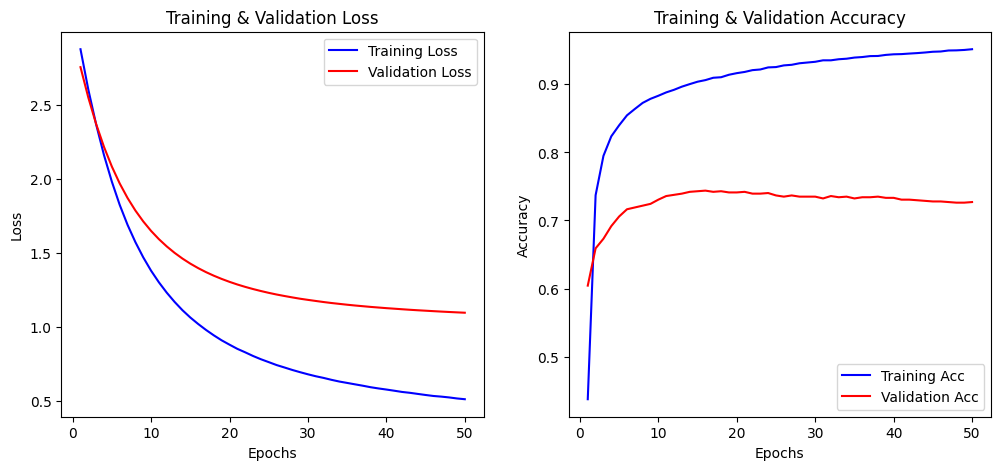

test_loss: 1.3093 and test_accuracy: 0.6620


In [11]:
# In sklearn's Logistic Regression, C is the inverse of regularization strength — a larger C means less regularization. 
# In PyTorch's Adam, weight_decay is the regularization strength directly — a larger value means more regularization. 
# So the they behave oppositely. 
torch.manual_seed(seed)
linear_classifier = LinearModel(X_train_tensor.shape[1], len(target_names))
criterion = nn.CrossEntropyLoss() # this applies softmax activation so you don't need to us nn.Softmax layer
patience = 10
num_epochs = 50
lr = 1e-3
train_classifier = train_test_model(
    device,
    linear_classifier,
    criterion,
    train_loader,
    val_loader,
    patience,
    num_epochs,
    lr,
    l2=1e-5
)
test_loss, test_accuracy = evaluate_model(train_classifier, test_loader, criterion, device, is_binary=False)
print(f"test_loss: {test_loss:.4f} and test_accuracy: {test_accuracy:.4f}")

In [12]:
config = {
        "model": LogisticRegression(solver="lbfgs", max_iter=1000, random_state=seed),
        "param_name": "C",
        "values": [0.01, 0.1, 1, 10,100]
    }
tune_sklearn_model(config["model"], 
                   config["param_name"],
                   config["values"],
                   X_train_sparse, y_train, X_test_sparse, y_test)


--- Tuning LogisticRegression (C) ---
C=0.01: Val Acc = 0.4509
C=0.1: Val Acc = 0.5762
C=1: Val Acc = 0.6547
C=10: Val Acc = 0.6483
C=100: Val Acc = 0.6410
🏆 Best C: 1 (Acc: 0.6547)



(1, 0.6546733935209772)

In [13]:
clean_memory()

Memory cleaned.


### Part 2: Multi-Layer Perceptron (MLP)

Now we add a **Hidden Layer** to capture non-linear relationships between words. This transforms our Linear Model into a Neural Network.

**Architecture:**
1. **Input Layer:** Size = `max_features` (e.g., 8000).
2. **Hidden Layer:** Size = 256. We use **ReLU** activation here to introduce non-linearity.
   $$ \text{ReLU}(x) = \max(0, x) $$
3. **Dropout:** Randomly zeroes out neurons during training to prevent overfitting.
5. **Output Layer:** Size = 20 (one score per class).

Other activation functions can be used is **GeLU**:
$$ \text{GELU}(x) = x \Phi(x) = x \cdot \frac{1}{2} \left[ 1 + \text{erf}\left( \frac{x}{\sqrt{2}} \right) \right] $$
$$ \text{erf}(x) = \frac{2}{\sqrt{\pi}} \int_{0}^{x} e^{-t^2} dt $$



In [14]:
class MLPModel(nn.Module):
    def __init__(self, feature_dim, hidden_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=feature_dim, out_features=hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_dim, out_features=output_dim)
        )
       

    def forward(self, X):
        return self.layers(X)

Epoch number 0 train_loss: 2.4339 and val_loss: 1.6655
Epoch number 0 train_accuracy: 0.4401 and val_accuracy: 0.6784
Epoch number 10 train_loss: 0.1382 and val_loss: 0.9011
Epoch number 10 train_accuracy: 0.9703 and val_accuracy: 0.7438
Early stopping at epoch number 15
Train_loss: 0.1124 and val_loss: 0.9426


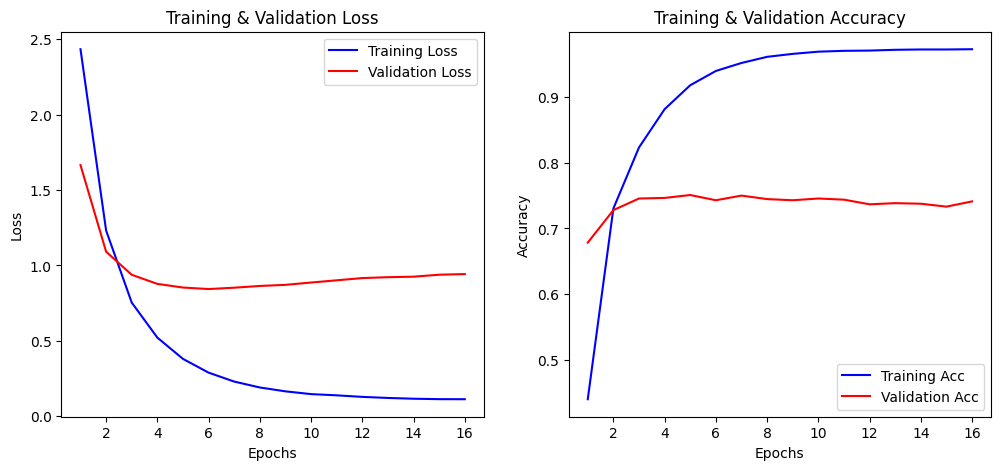

test_loss: 1.0863 and test_accuracy: 0.6788


In [15]:
# In sklearn's Logistic Regression, C is the inverse of regularization strength — a larger C means less regularization. 
# In PyTorch's Adam, weight_decay is the regularization strength directly — a larger value means more regularization. 
# So the they behave oppositely. 
torch.manual_seed(seed)
linear_classifier = MLPModel(X_train_tensor.shape[1], 256, len(target_names))
criterion = nn.CrossEntropyLoss() # this applies softmax activation so you don't need to us nn.Softmax layer
patience = 10
num_epochs = 50
lr = 1e-3
train_classifier = train_test_model(
    device,
    linear_classifier,
    criterion,
    train_loader,
    val_loader,
    patience,
    num_epochs,
    lr,
    l2=1e-5
)
test_loss, test_accuracy = evaluate_model(train_classifier, test_loader, criterion, device, is_binary=False)
print(f"test_loss: {test_loss:.4f} and test_accuracy: {test_accuracy:.4f}")

## Compare nonlinear layer with simple NaiveBayes
* given it uses conditional probablity, it should work pretty well in this type of application. 

In [16]:
config = {
        "model": MultinomialNB(),
        "param_name": "alpha",
        "values": [0.01, 0.1, 1, 5]
    }
tune_sklearn_model(config["model"], 
                   config["param_name"],
                   config["values"],
                   X_train_sparse, y_train, X_test_sparse, y_test)


--- Tuning MultinomialNB (alpha) ---
alpha=0.01: Val Acc = 0.6662
alpha=0.1: Val Acc = 0.6750
alpha=1: Val Acc = 0.6358
alpha=5: Val Acc = 0.5161
🏆 Best alpha: 0.1 (Acc: 0.6750)



(0.1, 0.6749867233138609)

## Model Performance Analysis

We observed that all three models—**Logistic Regression**, **Naive Bayes**, and the **PyTorch MLP**—achieved very similar accuracy scores (around **65%**) on the test set.

### **Summary of Results:**
- **Logistic Regression:** ~65% Accuracy
- **Naive Bayes:** ~67% Accuracy
- **PyTorch MLP:** ~67% Accuracy

### **Why is the performance so similar?**

1.  **Feature Limitation (The Bottleneck):**
    - We used **TF-IDF** with `max_features=10000`. This means all models are looking at the exact same limited vocabulary.
    - 10,000 words might capture the general topic, but it misses the "long tail" of specific keywords that distinguish nuanced topics (e.g., *ibm* vs *mac* hardware).
    - When the input features are the limiting factor, a more complex model (like an MLP) cannot extract much more information than a simple one.

2.  **The "Bag of Words" Ceiling:**
    - TF-IDF discards word order ("not good" becomes "good" + "not").
    - For topic classification, keyword presence is often enough, which is why linear models (Logistic Regression) and probabilistic models (Naive Bayes) are strong baselines.
    - Neural Networks typically shine when using **Word Embeddings** (Week 3) and **Sequence Models** (Week 4), which capture semantic meaning and word order.

3.  **Data Size vs. Model Complexity:**
    - The 20 Newsgroups dataset is relatively small (~10k training samples).
    - Deep Learning models usually require massive datasets to significantly outperform classical baselines. On smaller datasets, simple models often generalize just as well (or better) because they are less prone to overfitting.

### **Conclusion:**
For this specific setup (TF-IDF + Small Vocab), the **Naive Bayes** classifier is arguably the "winner" because it is computationally instant and requires almost no tuning, while achieving the same accuracy as the more complex Neural Network.